In [2]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

C:\Users\Divya S. Shekhawat\AppData\Local\Temp\ipykernel_27912\48198570.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\Divya S. Shekhawat\Downloads\CODING\AI\cRag\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [14]:
from pathlib import Path

C_DIR = Path.cwd()
P_DIR = C_DIR.parent

PDF_DIR = P_DIR / "documents"
print(PDF_DIR)

c:\Users\Divya S. Shekhawat\Downloads\CODING\AI\cRag\documents


In [16]:
docs = (
    PyPDFLoader(str(PDF_DIR / "book1.pdf")).load() +
    PyPDFLoader(str(PDF_DIR / "book2.pdf")).load() +
    PyPDFLoader(str(PDF_DIR / "book3.pdf")).load()
)

print(len(docs))

2123


In [18]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [20]:
len(chunks)

6393

In [23]:
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [26]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})


In [22]:
%pip install faiss-cpu

  Using cached faiss_cpu-1.14.3-cp313-cp313-win_amd64.whl.metadata (7.8 kB)
   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
    --------------------------------------- 0.3/16.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.2 MB 1.3 MB/s eta 0:00:13
   - -------------------------------------- 0.8/16.2 MB 1.4 MB/s eta 0:00:11
   -- ------------------------------------- 1.0/16.2 MB 1.4 MB/s eta 0:00:11
   -- ------------------------------------- 1.0/16.2 MB 1.4 MB/s eta 0:00:11
   -- ------------------------------------- 1.0/16.2 MB 1.4 MB/s eta 0:00:11
   --- ------------------------------------ 1.3/16.2 MB 861.6 kB/s eta 0:00:18
   --- ------------------------------------ 1.6/16.2 MB 876.4 kB/s eta 0:00:17
   ---- ----------------------------------- 1.8/16.2 MB 952.7 kB/s eta 0:00:16
   ----- ---------------------------------- 2.1/16.2 MB 950.8 kB/s eta 0:00:15
   ----- ----

In [24]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [41]:
class State(TypedDict):
    question : str
    docs : list[Document]
    answer : str

In [42]:
def retrieve(state):
    q = state["question"]
    return{"docs" : retriever.invoke(q)}

In [43]:
prompt= ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]

)

def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question" : state["question"], "context" : context})
    return {"answer" : out.content}

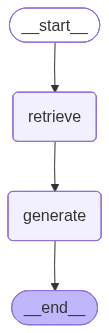

In [44]:
graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)


graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

app = graph.compile()

app

In [46]:
res = app.invoke({
    "question": "What is a transformer in deep learning.",
    "docs": [],
    "answer": ""
})

print(res["answer"])

The context does not provide a definition or explanation of a transformer in deep learning. Therefore, I don't know.
